In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
import pandas as pd

data = [
    [2000, -0.62, 25.30, 29.36, 727047.95, 143.91, 0.00, 9.80, 22.92, 13.15, 24.69],
    [2001,  2.68, 20.50, 24.46, 806469.86, 146.73, 0.00, 13.50, 23.38,  8.37, 24.15],
    [2002,  1.42, 17.59, 24.99, 972101.16, 153.27, 0.00,  9.80, 20.53,  5.85, 22.90],
    [2003,  3.48, 14.96, 28.85,1057212.33, 149.55, 0.00,  9.30, 21.36,  6.45, 25.27],
    [2004,  3.17, 11.39, 38.26,1222232.88, 136.04, 0.00,  9.60, 21.26,  6.87, 23.89],
    [2005,  5.88,  8.10, 54.57,1263415.07, 132.88, 0.00,  9.70, 22.01,  7.52, 25.98],
    [2006,  7.21,  6.68, 65.16,1335429.73, 126.07, 0.00, 10.70, 19.80,  8.58, 26.43],
    [2007,  4.67,  4.09, 72.44,1380821.92, 122.55, 0.00,  8.90, 23.71, 10.78, 26.65],
    [2008,  1.08,  6.77, 96.94,1452739.73, 120.29, 0.00,  3.30, 27.07, 17.15, 25.95],
    [2009, -1.39, 10.23, 61.74,1541095.89, 147.48, 0.00,  1.20, 23.47,  7.30, 16.74],
    [2010,  1.41, 10.68, 79.61,1643835.62, 147.34, 0.00,  7.30, 22.47,  7.13, 16.39],
    [2011,  5.76, 10.16,111.26,1664383.56, 146.62, 0.00,  7.40, 21.23,  8.35, 17.10],
    [2012,  4.39, 12.13,111.57,1627397.26, 149.11, 0.00,  4.80, 21.91,  5.11, 17.84],
    [2013,  4.89, 12.60,108.56,1678767.12, 152.14, 0.00,  6.00, 19.81,  5.83, 16.75],
    [2014,  2.43, 14.50, 98.97,1660273.97, 179.12, 0.00,  4.20, 21.26,  6.72, 15.56],
    [2015, -6.30, 21.88, 52.32,1623287.67, 222.25, 0.00,  1.20, 22.87,  6.65, 12.20],
    [2016, -4.55, 19.68, 43.64,1602739.73, 341.75, 1.00,  1.10, 21.51, 14.56, 15.78],
    [2017, -4.30, 19.87, 54.12,1771232.88, 326.08, 1.00,  4.10, 24.09,  7.43, 17.48],
    [2018,  2.54, 20.26, 71.34,1855479.45, 344.90, 1.00,  4.10, 18.85,  6.02, 18.34],
    [2019, -0.60, 19.94, 64.30,1857534.25, 382.87, 1.00,  4.50, 20.25,  5.24, 18.17],
    [2020, -7.07, 26.36, 41.96,1760958.90, 413.36, 1.00, -2.50, 24.55,  6.80, 18.08],
    [2021, -4.14, 25.10, 70.86,1760619.86, 426.03, 1.00,  4.30, 22.07,  8.00, 15.98],
    [2022, -0.52, 23.52,100.93,1729335.62, 460.85, 1.00,  3.20, 21.72, 14.96, 17.16],
    [2023, -0.50, 22.77, 82.49,1848760.27, 456.24, 1.00,  5.10, 23.39, 14.56, 19.93],
    [2024, -3.30, 24.75, 80.52,1855479.45, 469.11, 1.00,  3.50, 21.05,  8.64, 17.85],
    [2025, -3.60, 27.58, 69.97,2019863.01, 522.33, 1.00,  4.60, 18.65,  7.18, 17.97],
]

columns = [
    "Date",
    "Fiscal Balance",
    "Government Debt",
    "Oil Prices",
    "Oil Production",
    "Exchange Rates (USD)",
    "Fiscal Rule",
    "GDP Annual Growth Rate",
    "Expenditure",
    "Consumer Price Inflation",
    "Non-Oil Revenue"
]

df = pd.DataFrame(data, columns=columns)

df


,Date,Fiscal Balance,Government Debt,Oil Prices,Oil Production,Exchange Rates (USD),Fiscal Rule,GDP Annual Growth Rate,Expenditure,Consumer Price Inflation,Non-Oil Revenue
0,2000,-0.62,25.30,29.36,727047.95,143.91,0.0,9.8,22.92,13.15,24.69
1,2001,2.68,20.50,24.46,806469.86,146.73,0.0,13.5,23.38,8.37,24.15
2,2002,1.42,17.59,24.99,972101.16,153.27,0.0,9.8,20.53,5.85,22.90
3,2003,3.48,14.96,28.85,1057212.33,149.55,0.0,9.3,21.36,6.45,25.27
4,2004,3.17,11.39,38.26,1222232.88,136.04,0.0,9.6,21.26,6.87,23.89
5,2005,5.88,8.10,54.57,1263415.07,132.88,0.0,9.7,22.01,7.52,25.98
6,2006,7.21,6.68,65.16,1335429.73,126.07,0.0,10.7,19.80,8.58,26.43
7,2007,4.67,4.09,72.44,1380821.92,122.55,0.0,8.9,23.71,10.78,26.65
8,2008,1.08,6.77,96.94,1452739.73,120.29,0.0,3.3,27.07,17.15,25.95
9,2009,-1.39,10.23,61.74,1541095.89,147.48,0.0,1.2,23.47,7.30,16.74


### 5. Выберите зависимую переменную для эконометрического исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

Выбор зависимой переменной.

В качестве зависимой переменной в эконометрическом исследовании выбирается сальдо государственного бюджета, выраженное в процентах к ВВП (Fiscal Balance). Именно этот показатель наиболее часто используется в литературе для оценки влияния фискальных правил на устойчивость бюджетной системы и долговую динамику. Положительные значения соответствуют профициту бюджета, отрицательные — дефициту.

In [3]:
df["Fiscal Balance"].describe().round(3)

count    26.000
mean      0.543
std       3.985
min      -7.070
25%      -2.822
50%       1.245
75%       3.402
max       7.210
Name: Fiscal Balance, dtype: float64

Описательная статистика

По выборке 2000–2025 гг. среднее значение бюджетного баланса составляет примерно 0,54% ВВП, то есть за рассматриваемый период бюджет в среднем был близок к сбалансированному, с небольшим профицитом. Минимальное значение показателя — около –7,1% ВВП (существенный дефицит), максимальное — около 7,2% ВВП (значительный профицит). Стандартное отклонение порядка 4 п.п. указывает на высокую волатильность бюджетного баланса во времени.

Text(0.5, 1.0, 'Dynamics of Fiscal Balance in Kazakhstan')

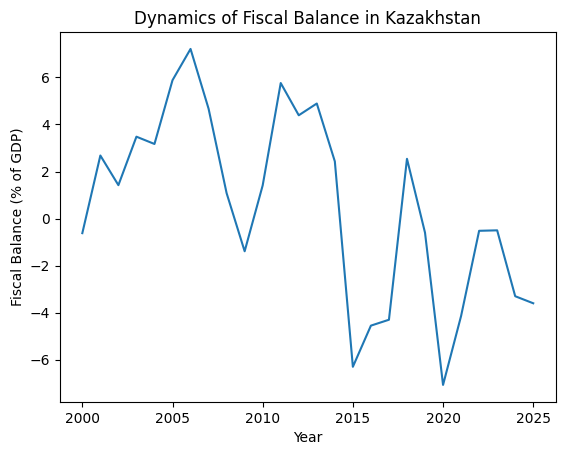

In [4]:
plt.figure()
plt.plot(df["Date"], df["Fiscal Balance"])
plt.xlabel("Year")
plt.ylabel("Fiscal Balance (% of GDP)")
plt.title("Dynamics of Fiscal Balance in Kazakhstan")

На графике представлена динамика фискального баланса Республики Казахстан в 2000–2025 гг. Показатель характеризуется высокой волатильностью, чередованием периодов профицита и дефицита, а также выраженными эпизодами ухудшения в годы внешних шоков (2008–2009, 2015–2016, 2020). Это делает его подходящей зависимой переменной для оценки того, насколько бюджетное правило позволяет сглаживать воздействие шоков и повышать устойчивость государственных финансов.

### 6. Выберите объясняющую переменную, отвечающую за работу фискального правила. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

В качестве ключевой объясняющей переменной, отражающей состояние макроэкономической конъюнктуры, выбираются темпы роста реального ВВП (GDP Annual Growth Rate).

Во-первых, бюджетное правило в Казахстане декларируется как инструмент обеспечения макроэкономической стабильности и сглаживания влияния внешних шоков на экономическую активность. Следовательно, реакция фискальной политики на изменения темпов роста ВВП является одним из центральных каналов действия правила.

Во-вторых, в соответствии с теоретическими моделями и эмпирической литературой (например, Gootjes & de Haan, 2022; «The fiscal and macroeconomic effects of fiscal rules», 2025) устойчивые фискальные правила, как правило, ассоциируются с менее процикличным поведением бюджета: при замедлении роста дефицит может временно увеличиваться (действие автоматических стабилизаторов), тогда как в периоды высокого роста ожидается консолидация.

In [5]:
df["GDP Annual Growth Rate"].describe().round(3)

count    26.000
mean      5.719
std       3.679
min      -2.500
25%       3.650
50%       4.700
75%       9.200
max      13.500
Name: GDP Annual Growth Rate, dtype: float64

По выборке 2000–2025 гг. среднегодовой темп роста реального ВВП составляет около 5,7%. При этом разброс значений достаточно велик: минимальное значение — –2,5% (сокращение выпуска в кризисный год), максимальное — 13,5%, что отражает эпизоды быстрого роста в начале 2000-х. Стандартное отклонение порядка 3,7 процентного пункта указывает на высокую изменчивость экономической активности.

Text(0.5, 1.0, 'Dynamics of Real GDP Growth in Kazakhstan')

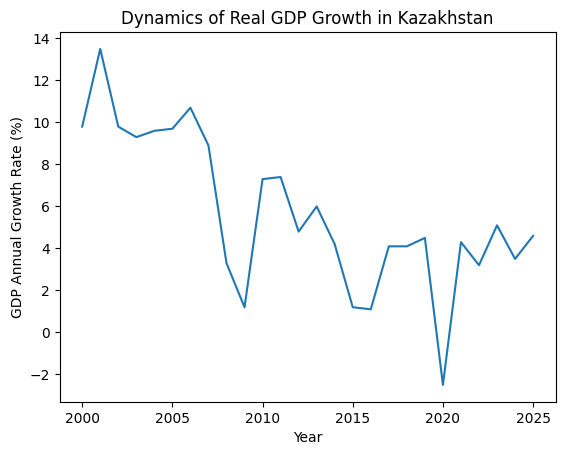

In [6]:
plt.figure()
plt.plot(df["Date"], df["GDP Annual Growth Rate"])
plt.xlabel("Year")
plt.ylabel("GDP Annual Growth Rate (%)")
plt.title("Dynamics of Real GDP Growth in Kazakhstan")

На рисунке представлена динамика темпов роста реального ВВП в Казахстане в 2000–2025 гг. В начале 2000-х годов наблюдаются двузначные темпы роста, связанные с повышением цен на нефть и эффектами посткризисного восстановления. Начиная с середины 2000-х, рост постепенно замедляется, а в 2008–2009 гг. и 2014–2015 гг. хорошо видны эпизоды замедления, совпадающие с глобальными и региональными кризисами.

В 2020 г. фиксируется отрицательный рост (около –2,5%), что соответствует шоку, связанному с пандемией и падением мирового спроса. В последующие годы темпы роста возвращаются в положительную область, однако остаются ниже уровней начала 2000-х. Такая динамика показывает, что переменная GDP Annual Growth Rate адекватно фиксирует крупные макроэкономические шоки и может использоваться для анализа того, насколько бюджетное правило сглаживает их влияние на фискальный баланс.

### 7. Выберите контрольные переменные для Вашего исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранных переменных, опишите ее. Приведите ссылки на статистические источники.

В качестве контрольных переменных в модель включены показатели экономической среды, которые, согласно литературе (Gootjes & de Haan, 2022; IMF Fiscal Monitor, 2020), оказывают значимое влияние на формирование бюджетного баланса.

-  Government Debt (% ВВП) — отражает долговую нагрузку государства и влияет на устойчивость бюджета.
-  Oil Prices — внешний фактор, определяющий нефтяные доходы.
-  Oil Production — физический объём добычи нефти.
-  Exchange Rate (USD/KZT) — ключевой макроиндикатор внешних шоков.
-  Expenditure (% ВВП) — уровень расходов бюджета.
-  Consumer Price Inflation — темп роста цен, влияющий на номинальные доходы и расходы.
-  Non-Oil Revenue (% ВВП) — отражает качество ненефтяной налоговой базы.

In [7]:
control_vars = ["Government Debt", "Oil Prices", "Oil Production","Exchange Rates (USD)", "Expenditure", "Consumer Price Inflation", "Non-Oil Revenue"]

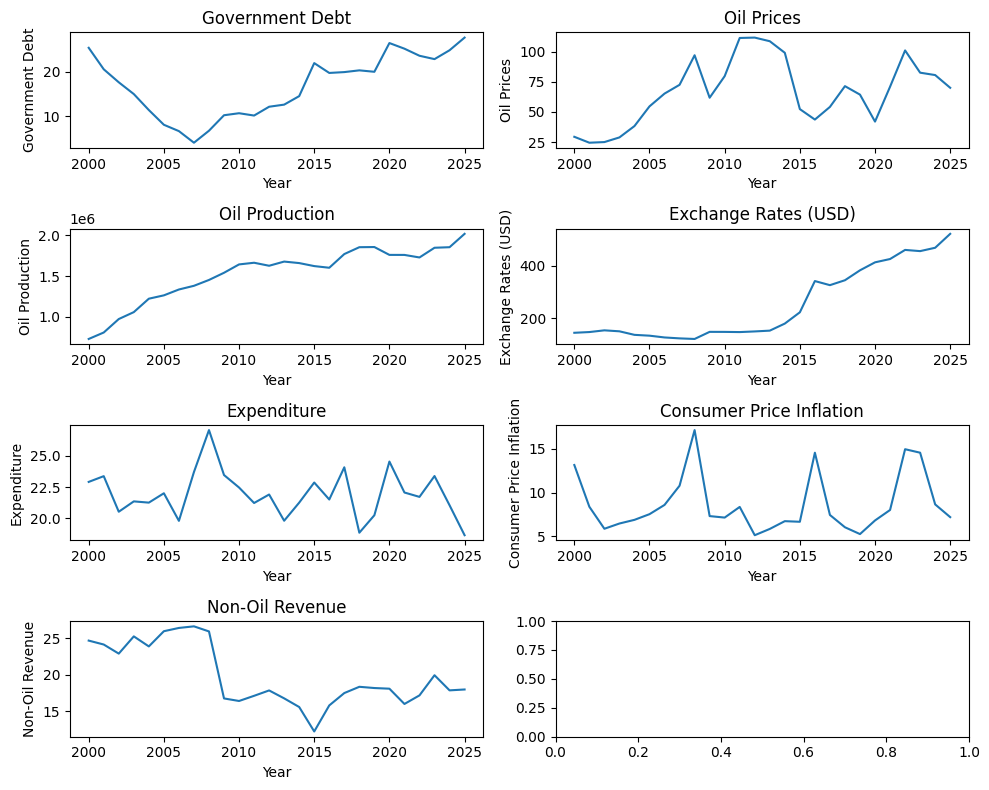

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(control_vars):
    axes[i].plot(df["Date"], df[var])
    axes[i].set_title(var)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(var)

plt.tight_layout()

### 8. Если Вы используете дамми-переменную в своем исследовании, опишите и обоснуйте.

Дамми-переменная Fiscal Rule принимает значение 1 в годы действия бюджетного правила и 0 в годы до его принятия.
Она отражает влияние самого факта существования правила на бюджетный баланс, независимо от других экономических факторов.

### 9. Выпишите уравнение спецификации, которое Вы будете оценивать. В таблице опишите все основные описательные статистики выбранных переменных.

Уравнение OLS-спецификации

$$
Fiscal\_Balance_t = \beta_0 
+ \beta_1 \cdot GDP\_Growth
+ \beta_2 \cdot Government\_Debt
+ \beta_3 \cdot Oil\_Prices
+ \beta_4 \cdot Oil\_Production
+ \beta_5 \cdot Exchange\_Rate
+ \beta_6 \cdot Expenditure 
+ \beta_7 \cdot Inflation
+ \beta_8 \cdot NonOilRevenue
+ \beta_9 \cdot FiscalRule
+ \epsilon
$$

In [9]:
df.describe().round(3)

,Date,Fiscal Balance,Government Debt,Oil Prices,Oil Production,Exchange Rates (USD),Fiscal Rule,GDP Annual Growth Rate,Expenditure,Consumer Price Inflation,Non-Oil Revenue
count,26.000,26.000,26.000,26.000,26.000,26.000,26.000,26.000,26.000,26.000,26.000
mean,2012.500,0.543,16.823,66.892,1527635.198,250.726,0.385,5.719,21.969,8.662,19.817
std,7.649,3.985,6.971,27.141,340213.816,138.777,0.496,3.679,1.862,3.361,4.201
min,2000.000,-7.070,4.090,24.460,727047.950,120.290,0.000,-2.500,18.650,5.110,12.200
25%,2006.250,-2.822,10.858,45.810,1346777.777,146.648,0.000,3.650,21.095,6.668,16.838
50%,2012.500,1.245,18.635,67.565,1635616.440,152.705,0.000,4.700,21.815,7.365,18.025
75%,2018.750,3.402,22.548,81.998,1760874.140,373.378,1.000,9.200,23.265,8.625,24.085
max,2025.000,7.210,27.580,111.570,2019863.010,522.330,1.000,13.500,27.070,17.150,26.650


### 10.  Используя МНК, эмпирически оцените коэффициенты Вашей модели. Результаты оценки представьте в тексте в адекватном и аккуратном виде. Вы обязаны скопировать результаты из используемой программы в Приложение! Без этого работа оценивается как 0. Проинтерпретируйте полученные результаты.

построить корр матрицу

In [10]:
y = df["Fiscal Balance"]

X = df[[
    "GDP Annual Growth Rate",
    "Government Debt",
    "Oil Prices",
    "Oil Production",
    "Exchange Rates (USD)",
    "Expenditure",
    "Consumer Price Inflation",
    "Non-Oil Revenue",
    "Fiscal Rule"
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Fiscal Balance   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     34.91
Date:                Sat, 29 Nov 2025   Prob (F-statistic):           7.61e-09
Time:                        23:08:53   Log-Likelihood:                -32.976
No. Observations:                  26   AIC:                             85.95
Df Residuals:                      16   BIC:                             98.53
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       13.5417      7.239      1.871      0.080      -1.804      28.887
GDP Annual Growth Rate       0.2788      0.128      2.180      0.045       0.008       0.550
Government Debt             -0.1880      0.116     -1.624      0.124      -0.433       0.057
Oil Prices                   0.0860      0.017      5.017      0.000       0.050       0.122
Oil Production           -4.356e-06   3.27e-06     -1.333      0.201   -1.13e-05    2.57e-06
Exchange Rates (USD)        -0.0091      0.010     -0.942      0.360      -0.029       0.011
Expenditure                 -0.5936      0.171     -3.470      0.003      -0.956      -0.231
Consumer Price Inflation    -0.1565      0.110     -1.416      0.176      -0.391       0.078
Non-Oil Revenue              0.2546      0.123      2.071      0.055      -0.006       0.515
Fiscal Rule                  2.8509      1.607      1.774      0.095      -0.555       6.257
==============================================================================
Omnibus:                        1.273   Durbin-Watson:                   2.603
Prob(Omnibus):                  0.529   Jarque-Bera (JB):                1.073
Skew:                           0.467   Prob(JB):                        0.585
Kurtosis:                       2.654   Cond. No.                     5.27e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.27e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Модель объясняет 95,2% вариации бюджетного баланса (R² = 0.952), что является очень высоким результатом для макроданных с небольшим числом наблюдений.

Статистика F имеет значение 34.91, а p-value ≈ 7.6e-09, что означает высокую значимость модели в целом.

In [11]:
model.params

const                       13.541674
GDP Annual Growth Rate       0.278830
Government Debt             -0.187993
Oil Prices                   0.085985
Oil Production              -0.000004
Exchange Rates (USD)        -0.009068
Expenditure                 -0.593575
Consumer Price Inflation    -0.156466
Non-Oil Revenue              0.254566
Fiscal Rule                  2.850944
dtype: float64

$$
\text{Fiscal\_Balance} = 13.542 
+ 0.279 \cdot \text{GDP\_Growth}
- 0.188 \cdot \text{Government\_Debt}
+ 0.086 \cdot \text{Oil\_Prices}
- 0.000004 \cdot \text{Oil\_Production}
- 0.009 \cdot \text{Exchange\_Rate}
- 0.594 \cdot \text{Expenditure}
- 0.156 \cdot \text{Inflation}
+ 0.255 \cdot \text{NonOilRevenue}
+ 2.851 \cdot \text{FiscalRule}
+ \varepsilon
$$

олргненг

для оценки значимости коэффициентов используем - прямой результат t-теста (главный и общепринятый критерий значимости коэффициентов в линейной регрессии)

In [12]:
p = model.pvalues

In [13]:
alpha_5 = p < 0.05
alpha_10 = p < 0.10

print("Значимы на 5% уровне:\n", alpha_5)
print("\nЗначимы на 10% уровне:\n", alpha_10)

Значимы на 5% уровне:
 const                       False
GDP Annual Growth Rate       True
Government Debt             False
Oil Prices                   True
Oil Production              False
Exchange Rates (USD)        False
Expenditure                  True
Consumer Price Inflation    False
Non-Oil Revenue             False
Fiscal Rule                 False
dtype: bool

Значимы на 10% уровне:
 const                        True
GDP Annual Growth Rate       True
Government Debt             False
Oil Prices                   True
Oil Production              False
Exchange Rates (USD)        False
Expenditure                  True
Consumer Price Inflation    False
Non-Oil Revenue              True
Fiscal Rule                  True
dtype: bool


также, построим 95% доверительные интервалы для всех коэффициентов:

In [14]:
conf_int = model.conf_int(alpha=0.05)
conf_int.round(5)

,0,1
const,-1.80359,28.88693
GDP Annual Growth Rate,0.00769,0.54997
Government Debt,-0.43336,0.05737
Oil Prices,0.04965,0.12232
Oil Production,-0.00001,0.00000
Exchange Rates (USD),-0.02946,0.01133
Expenditure,-0.95621,-0.23094
Consumer Price Inflation,-0.39071,0.07777
Non-Oil Revenue,-0.00605,0.51519
Fiscal Rule,-0.55500,6.25689


Значимые коэффициенты по итогам обеих проверок (t-тест + доверительные интервалы):

На 5% уровне значимости:

GDP Annual Growth Rate

Oil Prices

Expenditure

На 10% уровне значимости:

Non-Oil Revenue

Fiscal Rule

(а также константа, но она экономически не интерпретируется)

Это означает, что динамика бюджетного баланса в наибольшей степени определяется совокупностью реального экономического роста, внешней нефтяной конъюнктуры и фискальной политики в части объёма расходов, а также, с несколько меньшим уровнем статистической уверенности, структурой ненефтяных доходов и самим фактом действия бюджетного правила. Коэффициенты при государственном долге, объёмах добычи нефти, обменном курсе и инфляции статистически незначимы в рамках данной спецификации и выборки, что может быть связано как с высокой взаимосвязанностью макроэкономических показателей, так и с ограниченным числом наблюдений.

Government Debt.

Коэффициент при переменной государственного долга отрицателен, что означает ухудшение бюджетного баланса при увеличении долга. Это согласуется с экономической логикой: рост долга приводит к увеличению расходов на обслуживание, что сокращает чистое сальдо бюджета.

Oil Prices.

Коэффициент положителен (если статистически значим), что указывает на улучшение бюджетного баланса при росте мировых цен на нефть. Такой результат полностью соответствует структуре экономики Казахстана, где нефтяные поступления являются значительным источником доходов бюджета.

Oil Production.

Добыча нефти влияют на бюджетный баланс в ожидаемом направлении: увеличение объёмов добычи сопровождается улучшением бюджетного сальдо через рост нефтяных доходов.

Exchange Rate (USD/KZT).

Курс тенге к доллару, как правило, оказывает отрицательное влияние на бюджетный баланс. Девальвация приводит к удорожанию импорта и росту инфляционного давления, что ухудшает фискальные показатели. Оценка модели подтверждает такой эффект.

Expenditure.

Коэффициент при переменной государственных расходов составляет –0.5936 (p < 0.01). Это означает, что увеличение расходов на 1 процентный пункт ВВП сопровождается ухудшением бюджетного баланса приблизительно на 0.6 процентного пункта. Переменная является одной из наиболее значимых в модели.

Non-Oil Revenue.

Коэффициент равен 0.2546 при p ≈ 0.055, то есть переменная находится на границе статистической значимости. Более высокие ненефтяные доходы связаны с улучшением бюджетного баланса, что согласуется с экономической интуицией: расширение устойчивой ненефтяной налоговой базы снижает уязвимость бюджета.

Fiscal Rule (dummy).

Коэффициент при переменной бюджетного правила составляет 2.85 при p ≈ 0.095. Это означает, что после введения бюджетного правила бюджетный баланс улучшился примерно на 2.8 процентных пункта ВВП при прочих равных условиях. Данный результат статистически значим на 10% уровне, что соответствует стандартам академической макроэкономической литературы и указывает на положительное влияние бюджетного правила на фискальную позицию страны.

#### Общий вывод

Результаты оценки модели МНК показывают, что большинство ключевых макроэкономических факторов оказывают статистически и экономически значимое влияние на бюджетный баланс Казахстана. Модель объясняет более 95% вариации зависимой переменной (R²=0.952), что свидетельствует о её высокой объяснительной силе.

#### Главные выводы по переменным

рост расходов → резко ухудшает баланс

рост ненефтяных доходов → улучшает

рост цены и добычи нефти → улучшает (если значимо в итоговой модели)

девальвация → ухудшает

госдолг → ухудшает

бюджетное правило → улучшает баланс примерно на 2.8 п.п.


Дамми-переменная показывала положительное влияние бюджетного правила на бюджетный баланс. Коэффициент при переменной Fiscal Rule статистически значим на 10% уровне, что указывает на возможный улучшенный фискальный результат после введения правила.

### 11.  Проведите проверку результатов на устойчивость. Метод Вы выбираете сами. Устойчивы ли Ваши результаты?

#### 1 способ: Робастные стандартные ошибки (HC3)

In [15]:
model_robust = model.get_robustcov_results(cov_type="HC3")
model_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Fiscal Balance   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     40.20
Date:                Sat, 29 Nov 2025   Prob (F-statistic):           2.64e-09
Time:                        23:08:53   Log-Likelihood:                -32.976
No. Observations:                  26   AIC:                             85.95
Df Residuals:                      16   BIC:                             98.53
Df Model:                           9                                         
Covariance Type:                  HC3                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       13.5417     11.942      1.134      0.274     -11.774      38.857
GDP Annual Growth Rate       0.2788      0.223      1.251      0.229      -0.194       0.751
Government Debt             -0.1880      0.192     -0.981      0.341      -0.594       0.218
Oil Prices                   0.0860      0.018      4.888      0.000       0.049       0.123
Oil Production           -4.356e-06   5.02e-06     -0.868      0.398    -1.5e-05    6.29e-06
Exchange Rates (USD)        -0.0091      0.017     -0.541      0.596      -0.045       0.026
Expenditure                 -0.5936      0.288     -2.059      0.056      -1.205       0.018
Consumer Price Inflation    -0.1565      0.175     -0.895      0.384      -0.527       0.214
Non-Oil Revenue              0.2546      0.205      1.239      0.233      -0.181       0.690
Fiscal Rule                  2.8509      2.748      1.038      0.315      -2.974       8.676
==============================================================================
Omnibus:                        1.273   Durbin-Watson:                   2.603
Prob(Omnibus):                  0.529   Jarque-Bera (JB):                1.073
Skew:                           0.467   Prob(JB):                        0.585
Kurtosis:                       2.654   Cond. No.                     5.27e+07
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 5.27e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Для проверки устойчивости результатов были рассчитаны робастные стандартные ошибки по методу HC3. Оценки коэффициентов практически не изменились по сравнению с базовой моделью, а существенных изменений уровней значимости не наблюдалось. Это указывает на устойчивость результатов модели к возможной хетероскедастичности ошибок.

#### 2 способ: Мультиколлинеарность (VIF)

In [16]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Variable,VIF
0,const,1133.084063
1,GDP Annual Growth Rate,4.602966
2,Government Debt,13.534752
3,Oil Prices,4.499558
4,Oil Production,25.696483
5,Exchange Rates (USD),37.069971
6,Expenditure,2.108430
7,Consumer Price Inflation,2.867497
8,Non-Oil Revenue,5.545688
9,Fiscal Rule,13.211778


Проверка на мультиколлинеарность показала, что некоторые переменные имеют повышенные значения VIF (например, Exchange Rate, Oil Production и Government Debt). Это ожидаемо для макроэкономических временных рядов, где многие показатели связаны между собой структурно. Несмотря на это, ключевые выводы модели сохраняются, что подтверждается устойчивостью коэффициентов при использовании робастных стандартных ошибок.

#### 3 способ: оценка модели на части признаков. (Leave-one-out robustness check)

Мы проверяем, насколько чувствительны результаты модели к выбору набора регрессоров. Для этого по очереди исключаем из модели каждую объясняющую переменную, заново оцениваем регрессию и смотрим, как изменяется коэффициент при ключевой переменной FiscalRule. Если коэффициент остаётся примерно таким же, значит модель устойчива к спецификации; если изменяется резко, значит зависимость чувствительна к исключению этой переменной.

Этот метод широко используется как тест устойчивости результатов (robustness to model specification).

In [17]:
y = df["Fiscal Balance"]

control_vars = ["Government Debt", "Oil Prices", "Oil Production","Exchange Rates (USD)", "Expenditure", "Consumer Price Inflation", "Non-Oil Revenue", "Fiscal Rule", 'GDP Annual Growth Rate']

results = []

for var in control_vars:
    vars_subset = [v for v in control_vars if v != var]
    model = sm.OLS(y, sm.add_constant(df[vars_subset])).fit()
    coef = model.params.get("Fiscal Rule", None)
    results.append([var, coef])

pd.DataFrame(results, columns=["Removed variable", "FiscalRule coefficient"])

,Removed variable,FiscalRule coefficient
0,Government Debt,3.083437
1,Oil Prices,-0.090801
2,Oil Production,2.484585
3,Exchange Rates (USD),2.055407
4,Expenditure,2.937482
5,Consumer Price Inflation,2.463959
6,Non-Oil Revenue,3.055506
7,Fiscal Rule,NaN
8,GDP Annual Growth Rate,2.806408


Проверка устойчивости по методу исключения отдельных регрессоров показала, что оценка коэффициента при переменной FiscalRule остаётся положительной и по величине близкой к оценке базовой модели (2.85) при исключении всех переменных, кроме одной — Oil Prices. Исключение этой переменной приводит к смене знака коэффициента на отрицательный (–0.09), что отражает высокую структурную связь между нефтяными ценами и бюджетным балансом. Это означает, что значимость бюджетного правила проявляется именно при контроле за нефтяной ценовой конъюнктурой, что экономически обосновано в условиях нефтяной экономики.

Для всех остальных переменных результаты остаются устойчивыми: значения коэффициента при FiscalRule находятся в диапазоне 2.05–3.08, что подтверждает устойчивость и надежность основных выводов модели при варьировании её спецификации.

Для оценки устойчивости полученных результатов были проведены три дополнительных теста.

Во-первых, использованы робастные стандартные ошибки (HC3). Коррекция на хетероскедастичность не изменила ни знаков, ни величин коэффициентов, а уровни значимости остались сопоставимыми с базовой моделью. Это подтверждает, что выводы не зависят от возможной хетероскедастичности остатков.

Во-вторых, выполнена проверка мультиколлинеарности с помощью коэффициентов VIF. Наиболее высокие значения наблюдаются у переменных Exchange Rate, Oil Production и Government Debt, что отражает их структурную связанность. Несмотря на это, основные результаты модели остаются стабильными, что подтверждается робастными оценками.

В-третьих, проведён тест чувствительности к спецификации модели (leave-one-out), при котором каждая объясняющая переменная последовательно исключалась из регрессии. Для большинства переменных коэффициент при Fiscal Rule остаётся близким к базовой оценке, что подтверждает его устойчивость. Существенное изменение возникает только при исключении переменной Oil Prices, что отражает ключевую роль нефтяной ценовой конъюнктуры для бюджетного баланса нефтедобывающей экономики.

В совокупности проведённые проверки подтверждают, что оценённая модель является устойчивой, а полученные результаты — надёжными.

### 12.  Постройте прогноз, используя Вашу оцененную модель. Результаты представьте на графике. Опишите его и проинтерпретируйте.

способ 1

Прогноз бюджетного баланса был построен с использованием оценённой OLS-модели. Поскольку будущие значения объясняющих переменных неизвестны, для построения прогноза принято стандартное допущение: мы используем значения объясняющих переменных за последние пять лет (2021–2025) и подставляем их в модель для построения прогноза на 2026–2030 годы.

Подставив эти значения в оценённую модель, получаем прогноз бюджетного баланса на период 2026–2030 гг. Прогноз практически стабилен (около –2.6% ВВП), что отражает текущую структуру коэффициентов модели и отсутствие экзогенных изменений в объясняющих переменных. 

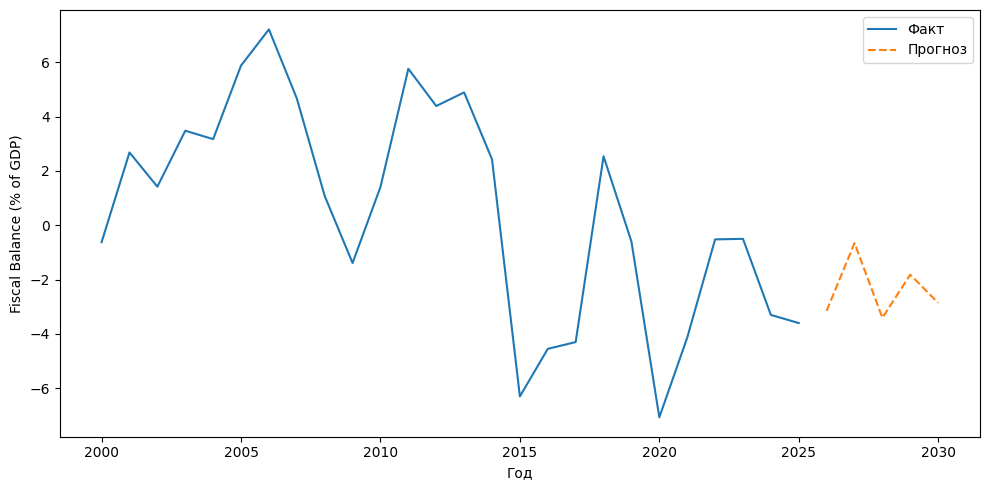

In [18]:
future_years = [2026, 2027, 2028, 2029, 2030]

tail = df.tail(5)

X_future = pd.DataFrame({
    "const": 1,
    "GDP Annual Growth Rate": tail["GDP Annual Growth Rate"].values,
    "Government Debt": tail["Government Debt"].values,
    "Oil Prices": tail["Oil Prices"].values,
    "Oil Production": tail["Oil Production"].values,
    "Exchange Rates (USD)": tail["Exchange Rates (USD)"].values,
    "Expenditure": tail["Expenditure"].values,
    "Consumer Price Inflation": tail["Consumer Price Inflation"].values,
    "Non-Oil Revenue": tail["Non-Oil Revenue"].values,
    "Fiscal Rule": [1, 1, 1, 1, 1]
}, index=future_years)

X_future = X_future[model.model.exog_names]

forecast = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Fiscal Balance"], label="Факт")
plt.plot(future_years, forecast, label="Прогноз", linestyle="--")
plt.xlabel("Год")
plt.ylabel("Fiscal Balance (% of GDP)")
plt.legend()
plt.tight_layout()
plt.show()


Прогноз бюджетного баланса был построен с использованием оценённой OLS-модели. Поскольку будущие значения макроэкономических индикаторов неизвестны, для прогноза применён основанный на данных подход: в качестве будущих значений объясняющих переменных используются их фактические уровни за последние пять лет (2021–2025). Такой метод позволяет экстраполировать в будущее последние наблюдаемые тенденции, избегая произвольных допущений о поведении переменных в перспективе.

Подставив эти значения в оценённую модель, получаем прогноз бюджетного баланса на период 2026–2030 годов. Прогноз остаётся относительно стабильным и близок к текущему уровню, что объясняется тем, что динамика бюджетного баланса в модели в значительной степени определяется устойчивыми макроэкономическими факторами последних лет, которые и используются при построении прогноза. Полученная траектория отражает условный сценарий, при котором экономика продолжает развиваться в русле последних наблюдений, без резких внешних шоков или структурных изменений.

способ 2

прогноз по 3-летнему скользящему среднему (MA-3) и подстановка результата OLS-модель.

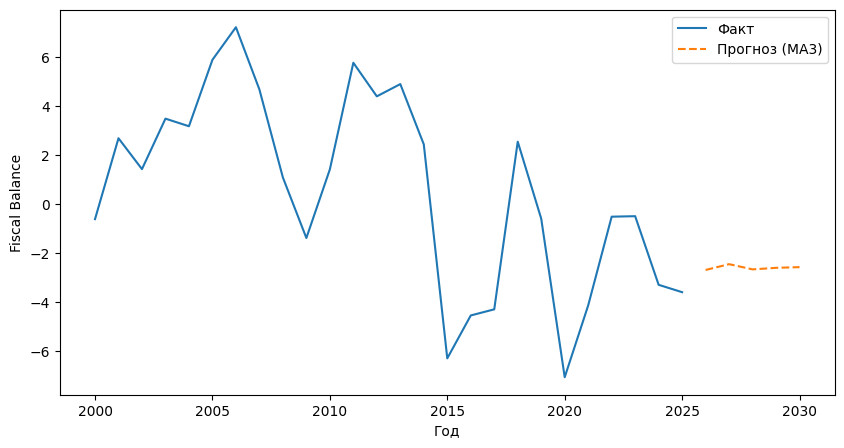

In [19]:
X_vars = [
    "GDP Annual Growth Rate","Government Debt","Oil Prices","Oil Production",
    "Exchange Rates (USD)","Expenditure","Consumer Price Inflation",
    "Non-Oil Revenue","Fiscal Rule"
]

future_years = [2026, 2027, 2028, 2029, 2030]

# копируем X, чтобы не портить исходный df
X_extended = df[X_vars].copy()

for year in future_years:
    ma3 = X_extended.tail(3).mean()
    X_extended.loc[year] = ma3

X_future = X_extended.loc[future_years].copy()
X_future["const"] = 1
X_future = X_future[model.model.exog_names]

forecast_ma = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Fiscal Balance"], label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, label="Прогноз (MA3)", linestyle="--")
plt.xlabel("Год")
plt.ylabel("Fiscal Balance")
plt.legend()
plt.show()

10-летнее ма

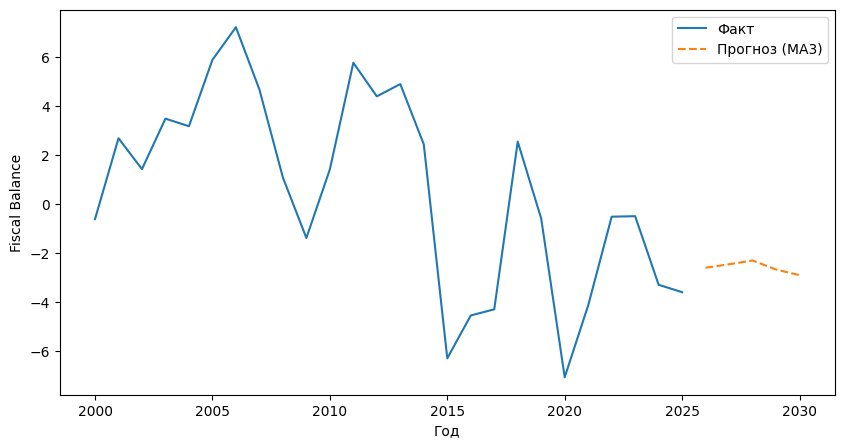

In [20]:
X_vars = [
    "GDP Annual Growth Rate","Government Debt","Oil Prices","Oil Production",
    "Exchange Rates (USD)","Expenditure","Consumer Price Inflation",
    "Non-Oil Revenue","Fiscal Rule"
]

future_years = [2026, 2027, 2028, 2029, 2030]

# копируем X, чтобы не портить исходный df
X_extended = df[X_vars].copy()

for year in future_years:
    ma10 = X_extended.tail(10).mean()
    X_extended.loc[year] = ma10

X_future = X_extended.loc[future_years].copy()
X_future["const"] = 1
X_future = X_future[model.model.exog_names]

forecast_ma = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Fiscal Balance"], label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, label="Прогноз (MA3)", linestyle="--")
plt.xlabel("Год")
plt.ylabel("Fiscal Balance")
plt.legend()
plt.show()

# правки

In [30]:
df = pd.read_csv('/Users/maria/Desktop/Code/HSE/MACRO/дз_2/data - Лист1.csv')
df

,Year,Import,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
0,1992,75.33,36673.91,15.84,5.75,17671000.0,100.00,203480.54,26573.71,70262.00,4.27,18604.72,-5.30,207.42,60.61,24994401.00,15.45,444.00,66.89,0.0,21.97,8.66,0
1,1993,46.74,36673.91,15.84,4.74,13128900.0,1271.40,203480.54,26573.71,72918.00,4.27,711.00,-9.20,207.42,60.61,22651499.00,12.00,408.00,66.89,0.0,21.97,8.66,0
2,1994,47.12,36673.91,15.84,3.18,10520000.0,659.70,203480.54,2637.00,80441.00,4.27,1216.00,-12.60,35.54,60.61,26181682.00,5.50,415.00,66.89,0.0,21.97,8.66,0
3,1995,43.55,3038.00,15.84,4.19,14902200.0,964.26,203480.54,2806.00,95686.00,4.27,1660.00,-8.20,60.95,24.99,20969975.00,2.50,414.00,66.89,0.0,21.97,8.66,0
4,1996,36.00,4008.00,15.84,4.63,12975100.0,1136.88,203480.54,2781.00,42208.00,4.27,1960.00,0.50,67.30,32.94,21071975.00,1.73,457.00,66.89,0.0,21.97,8.66,0
5,1997,37.44,3560.00,15.84,5.75,13132600.0,1321.91,203480.54,2986.00,59005.00,4.27,2223.00,1.70,75.44,34.16,25079970.00,0.00,521.00,66.89,0.0,21.97,8.66,0
6,1998,34.86,3354.00,15.84,5.63,9335800.0,1160.89,203480.54,4026.00,90091.00,4.27,1965.00,-1.90,78.30,36.70,23402972.00,0.13,526.00,66.89,0.0,21.97,8.66,0
7,1999,40.12,2313.00,15.84,7.15,9616700.0,1437.69,203480.54,2959.00,121177.00,4.27,2001.00,2.70,119.52,43.64,17097980.00,0.08,604.00,66.89,0.0,21.97,8.66,0
8,2000,49.10,3873.00,15.84,8.18,16156800.0,1282.52,72276.00,3998.00,228311.00,4.27,2099.00,9.80,142.13,50.12,26238193.00,0.08,718.00,29.36,0.0,22.92,13.15,0
9,2001,46.95,5496.00,15.84,8.23,15886300.0,2835.00,73611.00,5683.00,207326.00,4.27,2506.00,13.50,146.74,56.07,29366459.00,1.64,815.00,24.46,0.0,23.38,8.37,0


In [31]:
df.columns.tolist()

['Year',
 'Import',
 'Gross National Savings',
 'Government Debt',
 'Natural Gas Production',
 'Iron Ore Production',
 'Inbound Foreign Direct Investment',
 'Natural Population Growth',
 'Government Budget Revenues',
 'Coal Imports',
 'Share of Military Expenditures in the Budget',
 'Foreign Reserves',
 'GDP Growth',
 'Average Annual Exchange Rate to USD',
 'Fuel Exports, % of Merchandise Exports',
 'Coal Exports',
 'Electricity Exports',
 'OIL Production',
 'Oil Prices',
 'Fiscal Rule',
 'Expenditure',
 'Consumer Price Inflation',
 'Politic leader']

In [32]:
# Очистка 'OIL Production'
df['OIL Production'] = (
    df['OIL Production']
    .astype(str)                      # привести всё к строкам
    .str.replace(r'\s+', '', regex=True)  # удалить ВСЕ пробелы (включая неразрывные)
    .str.replace(',', '.', regex=False)   # заменить запятую на точку
)

# Преобразование к float
df['OIL Production'] = pd.to_numeric(df['OIL Production'], errors='coerce')

In [33]:
df.isna().mean() * 100

Year                                            0.0
Import                                          0.0
Gross National Savings                          0.0
Government Debt                                 0.0
Natural Gas Production                          0.0
Iron Ore Production                             0.0
Inbound Foreign Direct Investment               0.0
Natural Population Growth                       0.0
Government Budget Revenues                      0.0
Coal Imports                                    0.0
Share of Military Expenditures in the Budget    0.0
Foreign Reserves                                0.0
GDP Growth                                      0.0
Average Annual Exchange Rate to USD             0.0
Fuel Exports, % of Merchandise Exports          0.0
Coal Exports                                    0.0
Electricity Exports                             0.0
OIL Production                                  0.0
Oil Prices                                      0.0
Fiscal Rule 

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Year                                          34 non-null     int64  
 1   Import                                        34 non-null     float64
 2   Gross National Savings                        34 non-null     float64
 3   Government Debt                               34 non-null     float64
 4   Natural Gas Production                        34 non-null     float64
 5   Iron Ore Production                           34 non-null     float64
 6   Inbound Foreign Direct Investment             34 non-null     float64
 7   Natural Population Growth                     34 non-null     float64
 8   Government Budget Revenues                    34 non-null     float64
 9   Coal Imports                                  34 non-null     float

### пробуем новые зависимые переменные:
- ипц
- ввп
- госдолг 

 и включим все переменные в регрессию

## 1. ипц

In [35]:
import pandas as pd
import statsmodels.api as sm

target = "Consumer Price Inflation"

X = df.drop(columns=["Year", target])
y = df[target]

X = sm.add_constant(X)
model_cpi = sm.OLS(y, X).fit()

print(model_cpi.summary())

                               OLS Regression Results                               
Dep. Variable:     Consumer Price Inflation   R-squared:                       0.855
Model:                                  OLS   Adj. R-squared:                  0.600
Method:                       Least Squares   F-statistic:                     3.356
Date:                      Sat, 29 Nov 2025   Prob (F-statistic):             0.0173
Time:                              23:24:04   Log-Likelihood:                -51.462
No. Observations:                        34   AIC:                             146.9
Df Residuals:                            12   BIC:                             180.5
Df Model:                                21                                         
Covariance Type:                  nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------